In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

from lightgbm import LGBMClassifier

In [ ]:
df = pd.read_csv(r"E:\AARAV\Infotact-DS-ML\Project-1-Predictive-Maintenance\data\processed\model_ready_dataset.csv")

df.head()

,HDF,OSF,PWF,TWF,rpm_torque_interaction,Rotational speed [rpm],load_stress,Torque [Nm],load_density,Tool wear [min],temperature_ratio,tool_wear_mean_10,temperature_difference,air_temp_mean_10,UDI,Machine failure
0,0,0,0,0,71177.0,1306,29.7025,54.5,0.545,50,1.034806,36.8,10.4,298.60,19,0
1,0,0,0,0,53040.0,1632,10.5625,32.5,0.325,55,1.034794,40.2,10.4,298.64,20,0
2,0,0,0,0,58712.5,1375,18.2329,42.7,0.427,58,1.034794,43.6,10.4,298.69,21,0
3,0,0,0,0,64960.0,1450,20.0704,44.8,0.448,63,1.035141,47.0,10.5,298.71,22,0
4,0,0,0,0,48536.7,1581,9.4249,30.7,0.307,65,1.034794,50.1,10.4,298.74,23,0


In [3]:
X = df.drop("Machine failure", axis=1)

y = df["Machine failure"]

leak_columns = [
    "Machine failure",
    "UDI",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

X = X.drop(
    columns=[col for col in leak_columns if col in X.columns]
)

X.columns = (
    X.columns
    .str.replace("[","",regex=False)
    .str.replace("]","",regex=False)
    .str.replace("{","",regex=False)
    .str.replace("}","",regex=False)
    .str.replace(":","",regex=False)
    .str.replace(",","",regex=False)
)

In [ ]:
import joblib

model = joblib.load(r"E:\AARAV\Infotact-DS-ML\Project-1-Predictive-Maintenance\models\final_lightgbm_model.pkl")

In [5]:
predictions = model.predict(X)

prediction_df = pd.DataFrame({"Actual": y, "Predicted": predictions})

prediction_df.head()

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [6]:
errors = prediction_df[prediction_df["Actual"] != prediction_df["Predicted"]]

errors.head()

,Actual,Predicted
57,0,1
309,1,0
908,1,0
1067,1,0
1155,0,1


In [7]:
len(errors)

40

In [8]:
importance = pd.DataFrame({"Feature": X.columns, "Importance": model.feature_importances_})

importance = importance.sort_values(by="Importance", ascending=False)

importance.head(10)

,Feature,Importance
8,temperature_difference,3472
0,rpm_torque_interaction,1860
9,air_temp_mean_10,1081
1,Rotational speed rpm,884
5,Tool wear min,809
7,tool_wear_mean_10,683
2,load_stress,503
6,temperature_ratio,405
3,Torque Nm,103
4,load_density,0


In [ ]:
importance.to_csv(r"E:\AARAV\\Infotact-DS-ML\Project-1-Predictive-Maintenance\data\processed\feature_importance.csv", index=False)

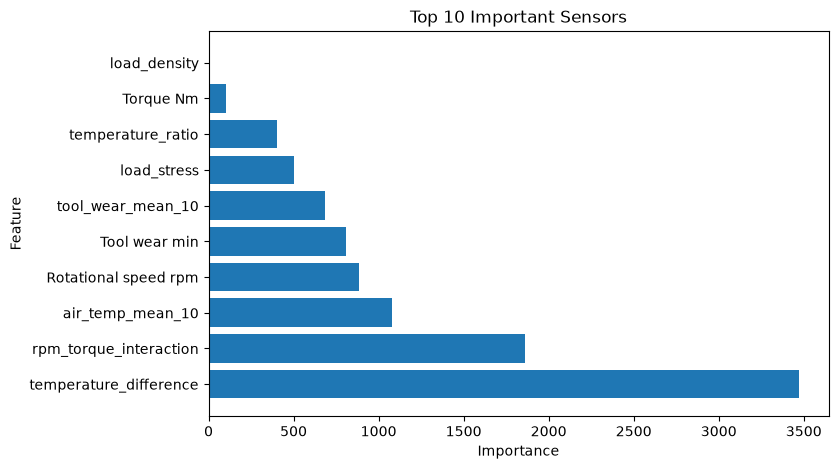

In [10]:
top_features = importance.head(10)

plt.figure(figsize=(8, 5))

plt.barh(top_features["Feature"], top_features["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top 10 Important Sensors")

plt.show()